# 0. Import Libraries

In [1]:
# Verify GPU is available
import tensorflow as tf
import torch

print("="*60)
print("GPU VERIFICATION")
print("="*60)

print("\nTensorFlow:")
print(f"  Version: {tf.__version__}")
print(f"  GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"  GPU Devices: {tf.config.list_physical_devices('GPU')}")

print("\nPyTorch:")
print(f"  CUDA Available: {torch.cuda.is_available()}")

print("\nNVIDIA GPU Info:")
!nvidia-smi --query-gpu=name,memory.total --format=csv

print("\n" + "="*60)


2025-11-20 01:34:56.815740: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763602497.027527      39 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763602497.083924      39 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


GPU VERIFICATION

TensorFlow:
  Version: 2.18.0
  GPU Available: True
  GPU Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

PyTorch:
  CUDA Available: True

NVIDIA GPU Info:
name, memory.total [MiB]
Tesla P100-PCIE-16GB, 16384 MiB



In [2]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import os
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
from tensorflow import keras
from keras.models import load_model
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Reshape, GRU, LSTM, Input, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import KFold

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


# 1. Load File Paths

In [3]:
# Check dataset structure
print("Available datasets:")
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

# Define paths
audio_path = '/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/'
genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

# Verify dataset
if os.path.exists(audio_path):
    print("\n✅ GTZAN Dataset found!")
    print(f"Genres: {genres}")
else:
    print("\n❌ Dataset not found! Please add GTZAN dataset from right panel.")


Available datasets:
/kaggle/input
/kaggle/input/gtzan-dataset-music-genre-classification
/kaggle/input/gtzan-dataset-music-genre-classification/Data
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/metal
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/reggae
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/blues
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/rock
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/classical
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/jazz
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/hiphop
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/country
/kaggle/input/gtzan-dataset-mus

In [4]:
all_files_path = []
all_genres = []

for i, genre in enumerate(genres):
    genre_path = audio_path + genre
    for _, dirname, files in os.walk(genre_path):
        for file in files:
            all_files_path.append(genre_path + "/" + file)
            all_genres.append(i)

# Split Train Val Test 8:1:1
X_file_train, X_file_test, y_file_train, y_file_test = train_test_split(all_files_path, all_genres, test_size = 0.1, 
                                                                        stratify=all_genres, random_state=42)
X_file_train, X_file_val, y_file_train, y_file_val = train_test_split(X_file_train, y_file_train, test_size = (1/9), 
                                                                      stratify=y_file_train, random_state=42)

# 2. Feature Extraction

## 2.A. No Split

In [ ]:
# Optimized feature extraction for 1D-CNN
def extract_mfcc_features(file_path, n_mfcc, max_pad_len=174):
    """
    Extract MFCC features with fixed length padding
    """
    try:
        # Load audio with fixed sample rate
        audio, sr = librosa.load(file_path, duration=30, mono=True, sr=22050)
        
        # Extract 40 MFCC coefficients
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        
        # Pad or truncate to fixed length
        if mfcc.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]
        
        return mfcc
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

print("✅ MFCC extraction function defined!")


In [ ]:
# Extract features from all audio files
features = []
labels = []

print("Extracting MFCC features from audio files...")
print("-" * 60)

for i, genre in enumerate(genres):
    genre_path = os.path.join(audio_path, genre)
    file_count = 0
    
    for filename in os.listdir(genre_path):
        if filename.endswith('.wav'):
            file_path = os.path.join(genre_path, filename)
            mfcc = extract_mfcc_features(file_path, n_mfcc=20)
            
            if mfcc is not None:
                features.append(mfcc)
                labels.append(i)
                file_count += 1
    
    print(f"{genre:12s}: {file_count} samples extracted")

print("-" * 60)
print(f"✅ Total samples extracted: {len(features)}")


In [ ]:
# Extract Mel-Spectrogram features for CRNN
def extract_melspectrogram(file_path, max_pad_len=174):
    """
    Extract mel-spectrogram features
    """
    try:
        audio, sr = librosa.load(file_path, duration=30, mono=True, sr=22050)
        
        # Create mel-spectrogram
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Pad or truncate
        if mel_spec_db.shape[1] < max_pad_len:
            pad_width = max_pad_len - mel_spec_db.shape[1]
            mel_spec_db = np.pad(mel_spec_db, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mel_spec_db = mel_spec_db[:, :max_pad_len]
        
        return mel_spec_db
    except Exception as e:
        print(f"Error: {e}")
        return None

print("✅ Mel-Spectrogram extraction function defined!")


In [ ]:
# Extract mel-spectrograms from all files
mel_features = []
mel_labels = []

print("Extracting Mel-Spectrogram features...")
print("-" * 60)

for i, genre in enumerate(genres):
    genre_path = os.path.join(audio_path, genre)
    file_count = 0
    
    for filename in os.listdir(genre_path):
        if filename.endswith('.wav'):
            file_path = os.path.join(genre_path, filename)
            mel = extract_melspectrogram(file_path)
            
            if mel is not None:
                mel_features.append(mel)
                mel_labels.append(i)
                file_count += 1
    
    print(f"{genre:12s}: {file_count} samples extracted")

print("-" * 60)
print(f"✅ Total mel-spectrograms extracted: {len(mel_features)}")


## 2.B. With Split

In [5]:
# CELL 27: Audio Segmentation for Data Augmentation
def extract_mfcc_segments(file_path, n_mfcc, segment_duration=3, segment_overlap=0.5, max_pad_len=130):
    """
    Split 30-sec audio into 3-sec segments for 20x more training data
    """
    try:
        audio, sr = librosa.load(file_path, duration=30, mono=True, sr=22050)
        segment_samples = segment_duration * sr
        segments_mfcc = []
        
        for start in range(0, len(audio) - segment_samples + 1, int(segment_samples*(1-segment_overlap))):
            segment = audio[start:start + segment_samples]
            mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=n_mfcc)
            
            if mfcc.shape[1] < max_pad_len:
                pad_width = max_pad_len - mfcc.shape[1]
                mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
            else:
                mfcc = mfcc[:, :max_pad_len]
            
            segments_mfcc.append(mfcc)
        
        return segments_mfcc
    except Exception as e:
        return []

def extract_mel_segments(file_path, segment_duration=3, n_fft=1024, segment_overlap=0.5, max_pad_len=129):
    """
    Split audio and extract mel-spectrograms from segments
    """
    try:
        audio, sr = librosa.load(file_path, duration=30, mono=True, sr=22050)
        segment_samples = segment_duration * sr
        segments_mel = []
        
        for start in range(0, len(audio) - segment_samples + 1, int(segment_samples*(1-segment_overlap))):
            segment = audio[start:start + segment_samples]
            mel_spec = librosa.feature.melspectrogram(y=segment, sr=sr, n_mels=128,
                                                  n_fft=n_fft, hop_length=512)
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            
            if mel_spec_db.shape[1] < max_pad_len:
                pad_width = max_pad_len - mel_spec_db.shape[1]
                mel_spec_db = np.pad(mel_spec_db, pad_width=((0, 0), (0, pad_width)), mode='constant')
            else:
                mel_spec_db = mel_spec_db[:, :max_pad_len]
            
            segments_mel.append(mel_spec_db)
        
        return segments_mel
    except Exception as e:
        return []

def extract_multi_features_segments(file_path, n_mfcc=20, n_fft=1024, segment_duration=3, segment_overlap=0.5, max_pad_len=130):
    try:
        audio, sr = librosa.load(file_path, duration=30, mono=True, sr=22050)
        segment_samples = segment_duration * sr
        hop_length = 512
        segments_all_features = []
       
        for start in range(0, len(audio) - segment_samples + 1, int(segment_samples * (1 - segment_overlap))):
            segment = audio[start : start + segment_samples]

            harmonic, percussive = librosa.effects.hpss(segment)

            mel_spec = librosa.feature.melspectrogram(y=segment, sr=sr, n_fft=n_fft, hop_length=hop_length)
            mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length)
            n_timesteps = mfcc.shape[1]

            zcr = librosa.feature.zero_crossing_rate(y=segment, hop_length=hop_length)[:, :n_timesteps]
            chroma_stft = librosa.feature.chroma_stft(y=segment, sr=sr, hop_length=hop_length)[:, :n_timesteps]
            rms = librosa.feature.rms(y=segment, hop_length=hop_length)[:, :n_timesteps]
            spec_cent = librosa.feature.spectral_centroid(y=segment, sr=sr, hop_length=hop_length)[:, :n_timesteps]
            spec_bw = librosa.feature.spectral_bandwidth(y=segment, sr=sr, hop_length=hop_length)[:, :n_timesteps]
            rolloff = librosa.feature.spectral_rolloff(y=segment, sr=sr, hop_length=hop_length)[:, :n_timesteps]
            harmony = librosa.feature.rms(y=harmonic, hop_length=hop_length)[:, :n_timesteps]
            percuss = librosa.feature.rms(y=percussive, hop_length=hop_length)[:, :n_timesteps]

            tempo, _ = librosa.beat.beat_track(y=segment, sr=sr)
            tempo_array = np.full((1, n_timesteps), tempo)

            all_features = np.vstack([mel_spec[:, :n_timesteps], mfcc, zcr, chroma_stft, rms, spec_cent, spec_bw, rolloff, harmony, percuss, tempo_array])
            
            if all_features.shape[1] < max_pad_len:
                pad_width = max_pad_len - all_features.shape[1]
                all_features = np.pad(all_features, pad_width=((0, 0), (0, pad_width)), mode='constant')
            else:
                all_features = all_features[:, :max_pad_len]
    
            segments_all_features.append(all_features)
        return segments_all_features
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return []
        

print("✅ Audio segmentation functions defined!")

✅ Audio segmentation functions defined!


In [6]:
def augment_noise(matrix, noise_factor=0.01):
    """Adds random Gaussian noise."""
    noise = np.random.normal(0, matrix.std() * noise_factor, matrix.shape)
    return matrix + noise

def augment_time_shift(matrix, shift_max=20):
    """Randomly shifts in time."""
    shift = np.random.randint(-shift_max, shift_max)
    return np.roll(matrix, shift, axis=1)

def augment_volume(matrix, min_factor=0.9, max_factor=1.1):
    """
    Applies a random volume change (gain) to a 2D matrix.
    """
    volume_factor = np.random.uniform(min_factor, max_factor)
    return matrix * volume_factor

def augment_specaugment(matrix, max_time_mask=20, max_freq_mask=5):
    """Applies Time and Frequency Masking (SpecAugment)."""
    spec = matrix.copy()
    
    # 1. Frequency Masking (Horizontal bar)
    freq_mask_width = np.random.randint(0, max_freq_mask)
    freq_start_point = np.random.randint(0, spec.shape[0] - freq_mask_width)
    spec[freq_start_point:freq_start_point + freq_mask_width, :] = 0

    # 2. Time Masking (Vertical bar)
    time_mask_width = np.random.randint(0, max_time_mask)
    time_start_point = np.random.randint(0, spec.shape[1] - time_mask_width)
    spec[:, time_start_point:time_start_point + time_mask_width] = 0
    
    return spec

In [ ]:
input_path = "/kaggle/input/music-genre-classification-dataset/features/features/"
output_path = "/kaggle/working/features/"

def extract_mfcc_features_from_file_path(X_file, y_file, augmentation, split_type):
    X_aug_mfcc = []
    y_aug_mfcc = []
    genre_mfcc_segment_counts = {i: 0 for i in range(10)}
    n_mfcc = 20
    segment_overlap = 0.5
    
    filename = f"{split_type}_mfcc{n_mfcc}_overlap{segment_overlap}.npz"
    load_path = input_path + filename
    save_path = output_path + filename
    
    if os.path.exists(load_path):
        data = np.load(load_path, allow_pickle=True)
        aug_mfcc = {
            'features': data['features'],
            'labels': data['labels'],
            'keys': data['keys']
        }
        print(f"MFCC Features Loaded. Shape = {aug_mfcc['features'].shape}")
        return aug_mfcc
    
    mfcc_keys = []
    for i, file_path in enumerate(X_file):
        current_genre = y_file[i]
        base = os.path.splitext(os.path.basename(file_path))[0]
        mfcc_segments = extract_mfcc_segments(file_path, n_mfcc=n_mfcc)
        
        for idx, segment in enumerate(mfcc_segments):
            key = f"{base}_{idx}"
            X_aug_mfcc.append(segment)
            y_aug_mfcc.append(current_genre)
            mfcc_keys.append(key)
            genre_mfcc_segment_counts[current_genre] += 1
            
            if augmentation:
                aug = augment_specaugment(segment)
                aug_key = f"{base}_{idx}_aug"
                X_aug_mfcc.append(aug)
                y_aug_mfcc.append(current_genre)
                mfcc_keys.append(aug_key)
                genre_mfcc_segment_counts[current_genre] += 1
    
    X_aug_mfcc = np.array(X_aug_mfcc)
    y_aug_mfcc = np.array(y_aug_mfcc)
    y_aug_mfcc = to_categorical(y_aug_mfcc, num_classes=10)
    
    os.makedirs(output_path, exist_ok=True)
    np.savez_compressed(save_path, 
                        features=X_aug_mfcc, 
                        labels=y_aug_mfcc, 
                        keys=np.array(mfcc_keys))
    print(f"MFCC Features Saved. Shape = {X_aug_mfcc.shape}")
    
    return {"features": X_aug_mfcc, "labels": y_aug_mfcc, "keys": np.array(mfcc_keys)}


def extract_mel_features_from_file_path(X_file, y_file, augmentation, split_type):
    X_aug_mel = []
    y_aug_mel = []
    genre_mel_segment_counts = {i: 0 for i in range(10)}
    segment_overlap = 0.5
    n_fft = 1024
    
    filename = f"{split_type}_mel{n_fft}_overlap{segment_overlap}.npz"
    load_path = input_path + filename
    save_path = output_path + filename
    
    if os.path.exists(load_path):
        data = np.load(load_path, allow_pickle=True)
        aug_mel = {
            'features': data['features'],
            'labels': data['labels'],
            'keys': data['keys']
        }
        print(f"Mel Features Loaded. Shape = {aug_mel['features'].shape}")
        return aug_mel
    
    mel_keys = []
    for i, file_path in enumerate(X_file):
        current_genre = y_file[i]
        base = os.path.splitext(os.path.basename(file_path))[0]
        mel_segments = extract_mel_segments(file_path, segment_overlap=segment_overlap, n_fft=n_fft)
        
        for idx, segment in enumerate(mel_segments):
            key = f"{base}_{idx}"
            X_aug_mel.append(segment)
            y_aug_mel.append(current_genre)
            mel_keys.append(key)
            genre_mel_segment_counts[current_genre] += 1
            
            if augmentation:
                aug = augment_specaugment(segment)
                aug_key = f"{base}_{idx}_aug"
                X_aug_mel.append(aug)
                y_aug_mel.append(current_genre)
                mel_keys.append(aug_key)
                genre_mel_segment_counts[current_genre] += 1
    
    # Convert to numpy arrays
    X_aug_mel = np.array(X_aug_mel)
    y_aug_mel = np.array(y_aug_mel)
    y_aug_mel = to_categorical(y_aug_mel, num_classes=10)
    
    os.makedirs(output_path, exist_ok=True)
    np.savez_compressed(save_path, 
                        features=X_aug_mel, 
                        labels=y_aug_mel, 
                        keys=np.array(mel_keys))
    print(f"Mel Features Saved. Shape = {X_aug_mel.shape}")
    
    return {"features": X_aug_mel, "labels": y_aug_mel, "keys": np.array(mel_keys)}


def extract_multi_features_from_file_path(X_file, y_file, augmentation, split_type):
    X_aug_multi = []
    y_aug_multi = []
    genre_multi_segment_counts = {i: 0 for i in range(10)}
    n_mfcc = 20
    n_fft=1024
    segment_overlap = 0.5
    
    filename = f"{split_type}_multi_mel{n_fft}_mfcc{n_mfcc}_overlap{segment_overlap}.npz"
    load_path = input_path + filename
    save_path = output_path + filename
    
    if os.path.exists(load_path):
        data = np.load(load_path, allow_pickle=True)
        aug_multi = {
            'features': data['features'],
            'labels': data['labels'],
            'keys': data['keys']
        }
        print(f"Multi Features Loaded. Shape = {aug_multi['features'].shape}")
        return aug_multi
    
    multi_keys = []
    for i, file_path in enumerate(X_file):
        current_genre = y_file[i]
        base = os.path.splitext(os.path.basename(file_path))[0]
        multi_segments = extract_multi_features_segments(file_path, n_mfcc=n_mfcc, n_fft=n_fft, segment_overlap=segment_overlap)
        
        for idx, segment in enumerate(multi_segments):
            key = f"{base}_{idx}"
            X_aug_multi.append(segment)
            y_aug_multi.append(current_genre)
            multi_keys.append(key)
            genre_multi_segment_counts[current_genre] += 1
            
            if augmentation:
                aug = augment_specaugment(segment)
                aug_key = f"{base}_{idx}_aug"
                X_aug_multi.append(aug)
                y_aug_multi.append(current_genre)
                multi_keys.append(aug_key)
                genre_multi_segment_counts[current_genre] += 1
    
    # Convert to numpy arrays
    X_aug_multi = np.array(X_aug_multi)
    y_aug_multi = np.array(y_aug_multi)
    y_aug_multi = to_categorical(y_aug_multi, num_classes=10)
    
    os.makedirs(output_path, exist_ok=True)
    np.savez_compressed(save_path, 
                        features=X_aug_multi, 
                        labels=y_aug_multi, 
                        keys=np.array(multi_keys))
    print(f"Multi Features Saved. Shape = {X_aug_multi.shape}")
    
    return {"features": X_aug_multi, "labels": y_aug_multi, "keys": np.array(multi_keys)}


def extract_multi_features_1d_from_file_path(X_file, y_file, augmentation, split_type):
    features_3s_df = pd.read_csv("/kaggle/input/gtzan-dataset-music-genre-classification/Data/features_3_sec.csv")
    X_aug_multi_1d = []
    y_aug_multi_1d = []
    multi_1d_keys = []
    for i, file_path in enumerate(X_file):
        current_genre = y_file[i]
        base = os.path.splitext(os.path.basename(file_path))[0]
        key = f"{base}"
        current_file_features = features_3s_df[features_3s_df['filename'].str.contains(base, na=False)].iloc[:, 2:-1].values
        X_aug_multi_1d.append(current_file_features)
        y_aug_multi_1d.append(current_genre)
        multi_1d_keys.append(key)
    
    # Convert to numpy arrays
    max_len = max(arr.shape[0] for arr in X_aug_multi_1d)
    feat_dim = X_aug_multi_1d[0].shape[1]
    X_padded = np.zeros((len(X_aug_multi_1d), max_len, feat_dim), dtype=np.float32)
    for i, arr in enumerate(X_aug_multi_1d):
        X_padded[i, :arr.shape[0], :] = arr
    y_aug_multi_1d = np.array(y_aug_multi_1d)
    y_aug_multi_1d = to_categorical(y_aug_multi_1d, num_classes=10)

    print(f"Multi Features 1D Made. Shape = {X_padded.shape}")
    
    return {"features": X_padded, "labels": y_aug_multi_1d, "keys": np.array(multi_1d_keys)}

In [8]:
print("🔃 Extracting Features for X train...")
train_aug_mfcc = extract_mfcc_features_from_file_path(X_file_train, y_file_train, augmentation=False, split_type="train")
train_aug_mel = extract_mel_features_from_file_path(X_file_train, y_file_train, augmentation=False, split_type="train")
train_aug_multi = extract_multi_features_from_file_path(X_file_train, y_file_train, augmentation=False, split_type="train")
print("🔃 Extracting Features for X val...")
val_aug_mfcc = extract_mfcc_features_from_file_path(X_file_val, y_file_val, augmentation=False, split_type="val")
val_aug_mel = extract_mel_features_from_file_path(X_file_val, y_file_val, augmentation=False, split_type="val")
val_aug_multi = extract_multi_features_from_file_path(X_file_val, y_file_val, augmentation=False, split_type="val")
print("🔃 Extracting Features for X test...")
test_aug_mfcc = extract_mfcc_features_from_file_path(X_file_test, y_file_test, augmentation=False, split_type="test")
test_aug_mel = extract_mel_features_from_file_path(X_file_test, y_file_test, augmentation=False, split_type="test")
test_aug_multi = extract_multi_features_from_file_path(X_file_test, y_file_test, augmentation=False, split_type="test")

X_train_aug_mfcc = train_aug_mfcc['features']
y_train_aug_mfcc = train_aug_mfcc['labels']

X_train_aug_mel = train_aug_mel['features']
y_train_aug_mel = train_aug_mel['labels']

X_train_aug_multi = train_aug_multi['features']
y_train_aug_multi = train_aug_multi['labels']

X_val_aug_mfcc = val_aug_mfcc['features']
y_val_aug_mfcc = val_aug_mfcc['labels']

X_val_aug_mel = val_aug_mel['features']
y_val_aug_mel = val_aug_mel['labels']

X_val_aug_multi = val_aug_multi['features']
y_val_aug_multi = val_aug_multi['labels']

X_test_aug_mfcc = test_aug_mfcc['features']
y_test_aug_mfcc = test_aug_mfcc['labels']

X_test_aug_mel = test_aug_mel['features']
y_test_aug_mel = test_aug_mel['labels']

X_test_aug_multi = test_aug_multi['features']
y_test_aug_multi = test_aug_multi['labels']

🔃 Extracting Features for X train...
MFCC Features Loaded. Shape = (15173, 20, 130)
Mel Features Loaded. Shape = (15173, 128, 129)
Multi Features Loaded. Shape = (15173, 168, 130)
🔃 Extracting Features for X val...
MFCC Features Loaded. Shape = (1900, 20, 130)
Mel Features Loaded. Shape = (1900, 128, 129)
Multi Features Loaded. Shape = (1900, 168, 130)
🔃 Extracting Features for X test...
MFCC Features Loaded. Shape = (1899, 20, 130)
Mel Features Loaded. Shape = (1899, 128, 129)
Multi Features Loaded. Shape = (1899, 168, 130)


In [36]:
print("🔃 Extracting Features for X train...")
train_aug_multi_1d = extract_multi_features_1d_from_file_path(X_file_train, y_file_train, augmentation=False, split_type="train")
print("🔃 Extracting Features for X val...")
val_aug_multi_1d = extract_multi_features_1d_from_file_path(X_file_val, y_file_val, augmentation=False, split_type="val")
print("🔃 Extracting Features for X test...")
test_aug_multi_1d = extract_multi_features_1d_from_file_path(X_file_test, y_file_test, augmentation=False, split_type="test")

X_train_aug_multi_1d = train_aug_multi_1d['features']
y_train_aug_multi_1d = train_aug_multi_1d['labels']
X_val_aug_multi_1d = val_aug_multi_1d['features']
y_val_aug_multi_1d = val_aug_multi_1d['labels']
X_test_aug_multi_1d = test_aug_multi_1d['features']
y_test_aug_multi_1d = test_aug_multi_1d['labels']

🔃 Extracting Features for X train...
Multi Features 1D Made. Shape = (800, 10, 57)
🔃 Extracting Features for X val...
Multi Features 1D Made. Shape = (100, 10, 57)
🔃 Extracting Features for X test...
Multi Features 1D Made. Shape = (100, 10, 57)


In [9]:
# Prepare Augmented Data for 2D-CNN

# Normalize
X_train_aug_mfcc_reshaped = X_train_aug_mfcc.reshape(X_train_aug_mfcc.shape[0], -1)
X_test_aug_mfcc_reshaped = X_test_aug_mfcc.reshape(X_test_aug_mfcc.shape[0], -1)
X_val_aug_mfcc_reshaped = X_val_aug_mfcc.reshape(X_val_aug_mfcc.shape[0], -1)
scaler_aug_mfcc = StandardScaler()
X_train_aug_mfcc_scaled = scaler_aug_mfcc.fit_transform(X_train_aug_mfcc_reshaped)
X_test_aug_mfcc_scaled = scaler_aug_mfcc.transform(X_test_aug_mfcc_reshaped)
X_val_aug_mfcc_scaled = scaler_aug_mfcc.transform(X_val_aug_mfcc_reshaped)
X_train_aug_mfcc = X_train_aug_mfcc_scaled.reshape(X_train_aug_mfcc.shape[0], X_train_aug_mfcc.shape[1], X_train_aug_mfcc.shape[2])
X_val_aug_mfcc = X_val_aug_mfcc_scaled.reshape(X_val_aug_mfcc.shape[0], X_val_aug_mfcc.shape[1], X_val_aug_mfcc.shape[2])
X_test_aug_mfcc = X_test_aug_mfcc_scaled.reshape(X_test_aug_mfcc.shape[0], X_test_aug_mfcc.shape[1], X_test_aug_mfcc.shape[2])

# Reshape for 2D-CNN
X_train_aug_mfcc = X_train_aug_mfcc.reshape(X_train_aug_mfcc.shape[0], X_train_aug_mfcc.shape[1], X_train_aug_mfcc.shape[2], 1)
X_val_aug_mfcc = X_val_aug_mfcc.reshape(X_val_aug_mfcc.shape[0], X_val_aug_mfcc.shape[1], X_val_aug_mfcc.shape[2], 1)
X_test_aug_mfcc = X_test_aug_mfcc.reshape(X_test_aug_mfcc.shape[0], X_test_aug_mfcc.shape[1], X_test_aug_mfcc.shape[2], 1)

print(f"✅ Augmented 2D-CNN data prepared!")
print(f"Training shape: {X_train_aug_mfcc.shape}")
print(f"Validation shape: {X_val_aug_mfcc.shape}")
print(f"Test shape: {X_test_aug_mfcc.shape}")

✅ Augmented 2D-CNN data prepared!
Training shape: (15173, 20, 130, 1)
Validation shape: (1900, 20, 130, 1)
Test shape: (1899, 20, 130, 1)


In [10]:
# Prepare Augmented Data for 2D-CNN

# Normalize
X_train_aug_mel_reshaped = X_train_aug_mel.reshape(X_train_aug_mel.shape[0], -1)
X_test_aug_mel_reshaped = X_test_aug_mel.reshape(X_test_aug_mel.shape[0], -1)
X_val_aug_mel_reshaped = X_val_aug_mel.reshape(X_val_aug_mel.shape[0], -1)
scaler_aug_mel = StandardScaler()
X_train_aug_mel_scaled = scaler_aug_mel.fit_transform(X_train_aug_mel_reshaped)
X_test_aug_mel_scaled = scaler_aug_mel.transform(X_test_aug_mel_reshaped)
X_val_aug_mel_scaled = scaler_aug_mel.transform(X_val_aug_mel_reshaped)
X_train_aug_mel = X_train_aug_mel_scaled.reshape(X_train_aug_mel.shape[0], X_train_aug_mel.shape[1], X_train_aug_mel.shape[2])
X_val_aug_mel = X_val_aug_mel_scaled.reshape(X_val_aug_mel.shape[0], X_val_aug_mel.shape[1], X_val_aug_mel.shape[2])
X_test_aug_mel = X_test_aug_mel_scaled.reshape(X_test_aug_mel.shape[0], X_test_aug_mel.shape[1], X_test_aug_mel.shape[2])

# Reshape for 2D-CNN
X_train_aug_mel = X_train_aug_mel.reshape(X_train_aug_mel.shape[0], X_train_aug_mel.shape[1], X_train_aug_mel.shape[2], 1)
X_val_aug_mel = X_val_aug_mel.reshape(X_val_aug_mel.shape[0], X_val_aug_mel.shape[1], X_val_aug_mel.shape[2], 1)
X_test_aug_mel = X_test_aug_mel.reshape(X_test_aug_mel.shape[0], X_test_aug_mel.shape[1], X_test_aug_mel.shape[2], 1)

print(f"✅ Augmented 2D-CNN data prepared!")
print(f"Training shape: {X_train_aug_mel.shape}")
print(f"Validation shape: {X_val_aug_mel.shape}")
print(f"Test shape: {X_test_aug_mel.shape}")

✅ Augmented 2D-CNN data prepared!
Training shape: (15173, 128, 129, 1)
Validation shape: (1900, 128, 129, 1)
Test shape: (1899, 128, 129, 1)


In [11]:
# Prepare Augmented Data for 2D-CNN

# Normalize
X_train_aug_multi_reshaped = X_train_aug_multi.reshape(X_train_aug_multi.shape[0], -1)
X_test_aug_multi_reshaped = X_test_aug_multi.reshape(X_test_aug_multi.shape[0], -1)
X_val_aug_multi_reshaped = X_val_aug_multi.reshape(X_val_aug_multi.shape[0], -1)
scaler_aug_multi = StandardScaler()
X_train_aug_multi_scaled = scaler_aug_multi.fit_transform(X_train_aug_multi_reshaped)
X_test_aug_multi_scaled = scaler_aug_multi.transform(X_test_aug_multi_reshaped)
X_val_aug_multi_scaled = scaler_aug_multi.transform(X_val_aug_multi_reshaped)
X_train_aug_multi = X_train_aug_multi_scaled.reshape(X_train_aug_multi.shape[0], X_train_aug_multi.shape[1], X_train_aug_multi.shape[2])
X_val_aug_multi = X_val_aug_multi_scaled.reshape(X_val_aug_multi.shape[0], X_val_aug_multi.shape[1], X_val_aug_multi.shape[2])
X_test_aug_multi = X_test_aug_multi_scaled.reshape(X_test_aug_multi.shape[0], X_test_aug_multi.shape[1], X_test_aug_multi.shape[2])

# Reshape for 2D-CNN
X_train_aug_multi = X_train_aug_multi.reshape(X_train_aug_multi.shape[0], X_train_aug_multi.shape[1], X_train_aug_multi.shape[2], 1)
X_val_aug_multi = X_val_aug_multi.reshape(X_val_aug_multi.shape[0], X_val_aug_multi.shape[1], X_val_aug_multi.shape[2], 1)
X_test_aug_multi = X_test_aug_multi.reshape(X_test_aug_multi.shape[0], X_test_aug_multi.shape[1], X_test_aug_multi.shape[2], 1)

print(f"✅ Augmented 2D-CNN data prepared!")
print(f"Training shape: {X_train_aug_multi.shape}")
print(f"Validation shape: {X_val_aug_multi.shape}")
print(f"Test shape: {X_test_aug_multi.shape}")

✅ Augmented 2D-CNN data prepared!
Training shape: (15173, 168, 130, 1)
Validation shape: (1900, 168, 130, 1)
Test shape: (1899, 168, 130, 1)


In [ ]:
# Prepare Augmented Data for 1D-CNN / RNN

# Normalize
X_train_aug_multi_1d_reshaped = X_train_aug_multi_1d.reshape(X_train_aug_multi_1d.shape[0], -1)
X_test_aug_multi_1d_reshaped = X_test_aug_multi_1d.reshape(X_test_aug_multi_1d.shape[0], -1)
X_val_aug_multi_1d_reshaped = X_val_aug_multi_1d.reshape(X_val_aug_multi_1d.shape[0], -1)
scaler_aug_multi_1d = StandardScaler()
X_train_aug_multi_1d_scaled = scaler_aug_multi_1d.fit_transform(X_train_aug_multi_1d_reshaped)
X_test_aug_multi_1d_scaled = scaler_aug_multi_1d.transform(X_test_aug_multi_1d_reshaped)
X_val_aug_multi_1d_scaled = scaler_aug_multi_1d.transform(X_val_aug_multi_1d_reshaped)
X_train_aug_multi_1d = X_train_aug_multi_1d_scaled.reshape(X_train_aug_multi_1d.shape[0], X_train_aug_multi_1d.shape[1], X_train_aug_multi_1d.shape[2])
X_val_aug_multi_1d = X_val_aug_multi_1d_scaled.reshape(X_val_aug_multi_1d.shape[0], X_val_aug_multi_1d.shape[1], X_val_aug_multi_1d.shape[2])
X_test_aug_multi_1d = X_test_aug_multi_1d_scaled.reshape(X_test_aug_multi_1d.shape[0], X_test_aug_multi_1d.shape[1], X_test_aug_multi_1d.shape[2])

# Reshape for 1D-CNN / RNN
X_train_aug_multi_1d = X_train_aug_multi_1d.reshape(X_train_aug_multi_1d.shape[0], X_train_aug_multi_1d.shape[2], X_train_aug_multi_1d.shape[1])
X_val_aug_multi_1d = X_val_aug_multi_1d.reshape(X_val_aug_multi_1d.shape[0], X_val_aug_multi_1d.shape[2], X_val_aug_multi_1d.shape[1])
X_test_aug_multi_1d = X_test_aug_multi_1d.reshape(X_test_aug_multi_1d.shape[0], X_test_aug_multi_1d.shape[2], X_test_aug_multi_1d.shape[1])

print(f"✅ Augmented 1D-CNN / RNN data prepared!")
print(f"Training shape: {X_train_aug_multi_1d.shape}")
print(f"Validation shape: {X_val_aug_multi_1d.shape}")
print(f"Test shape: {X_test_aug_multi_1d.shape}")

✅ Augmented 1D-CNN / RNN data prepared!
Training shape: (800, 57, 10)
Validation shape: (100, 57, 10)
Test shape: (100, 57, 10)


# 3. Model

In [40]:
def create_cnn_lstm_model(input_shape, n_conv=3, batch_normalization=False, rnn_layers = 3):
    input_layer = Input(shape=input_shape)

    for i in range(0, n_conv):
        x = Conv2D(128, (5, 5), activation='relu', padding='same')(input_layer)
        x = MaxPooling2D((2, 2))(x)
        if batch_normalization:
            x = BatchNormalization()(x)
        x = Dropout(0.25)(x)
    
    shape = x.shape
    x = Reshape((shape[1], shape[2] * shape[3]))(x)
    
    x = LSTM(128, return_sequences=True)(x)
    x = LSTM(128, return_sequences=True)(x)
    x = LSTM(64, return_sequences=True)(x)
    
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    if batch_normalization:
        x = BatchNormalization()(x)
    output_layer = Dense(10, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output_layer)
    return model

def create_cnn_lstm_model_1d(input_shape, n_conv=3, batch_normalization=False, rnn_layers = 3):
    input_layer = Input(shape=input_shape)

    for i in range(0, n_conv):
        x = Conv1D(128, 5, activation='relu', padding='same')(input_layer)
        x = MaxPooling1D(2)(x)
        if batch_normalization:
            x = BatchNormalization()(x)
        x = Dropout(0.25)(x)
    
    x = LSTM(128, return_sequences=True)(x)
    x = LSTM(128, return_sequences=True)(x)
    x = LSTM(64, return_sequences=True)(x)
    
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    if batch_normalization:
        x = BatchNormalization()(x)
    output_layer = Dense(10, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output_layer)
    return model

    
def create_cnn_gru_model(input_shape, n_conv=3, batch_normalization=False):
    input_layer = Input(shape=input_shape)
    
    for i in range(0, n_conv):
        x = Conv2D(128, (5, 5), activation='relu', padding='same')(input_layer)
        x = MaxPooling2D((2, 2))(x)
        if batch_normalization:
            x = BatchNormalization()(x)
        x = Dropout(0.25)(x)
    
    shape = x.shape
    x = Reshape((shape[1], shape[2] * shape[3]))(x)
    
    x = GRU(128, return_sequences=True)(x)
    x = GRU(128, return_sequences=True)(x)
    x = GRU(64, return_sequences=True)(x)
    
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    if batch_normalization:
        x = BatchNormalization()(x)
    output_layer = Dense(10, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output_layer)
    return model

def create_cnn_gru_model_1d(input_shape, n_conv=3, batch_normalization=False, rnn_layers = 3):
    input_layer = Input(shape=input_shape)

    for i in range(0, n_conv):
        x = Conv1D(128, 5, activation='relu', padding='same')(input_layer)
        x = MaxPooling1D(2)(x)
        if batch_normalization:
            x = BatchNormalization()(x)
        x = Dropout(0.25)(x)
    
    x = GRU(128, return_sequences=True)(x)
    x = GRU(128, return_sequences=True)(x)
    x = GRU(64, return_sequences=True)(x)
    
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    if batch_normalization:
        x = BatchNormalization()(x)
    output_layer = Dense(10, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output_layer)
    return model


def create_cnn_bilstm_model(input_shape, n_conv=3, batch_normalization=False):
    input_layer = Input(shape=input_shape)
    
    for i in range(0, n_conv):
        x = Conv2D(128, (5, 5), activation='relu', padding='same')(input_layer)
        x = MaxPooling2D((2, 2))(x)
        if batch_normalization:
            x = BatchNormalization()(x)
        x = Dropout(0.25)(x)
    
    shape = x.shape
    x = Reshape((shape[1], shape[2] * shape[3]))(x)
    
    x = LSTM(128, return_sequences=True)(x)
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = LSTM(64, return_sequences=True)(x)
    
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    if batch_normalization:
        x = BatchNormalization()(x)
    output_layer = Dense(10, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output_layer)
    return model

def create_cnn_bilstm_model_1d(input_shape, n_conv=3, batch_normalization=False, rnn_layers = 3):
    input_layer = Input(shape=input_shape)

    for i in range(0, n_conv):
        x = Conv1D(128, 5, activation='relu', padding='same')(input_layer)
        x = MaxPooling1D(2)(x)
        if batch_normalization:
            x = BatchNormalization()(x)
        x = Dropout(0.25)(x)
    
    x = LSTM(128, return_sequences=True)(x)
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = LSTM(64, return_sequences=True)(x)
    
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    if batch_normalization:
        x = BatchNormalization()(x)
    output_layer = Dense(10, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output_layer)
    return model

def create_cnn_bigru_model(input_shape, n_conv=3, batch_normalization=False):
    input_layer = Input(shape=input_shape)
    
    for i in range(0, n_conv):
        x = Conv2D(128, (5, 5), activation='relu', padding='same')(input_layer)
        x = MaxPooling2D((2, 2))(x)
        if batch_normalization:
            x = BatchNormalization()(x)
        x = Dropout(0.25)(x)
    
    shape = x.shape
    x = Reshape((shape[1], shape[2] * shape[3]))(x)
    
    x = GRU(128, return_sequences=True)(x)
    x = Bidirectional(GRU(128, return_sequences=True))(x)
    x = GRU(64, return_sequences=True)(x)
    
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    if batch_normalization:
        x = BatchNormalization()(x)
    output_layer = Dense(10, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output_layer)
    return model

def create_cnn_bigru_model_1d(input_shape, n_conv=3, batch_normalization=False, rnn_layers = 3):
    input_layer = Input(shape=input_shape)

    for i in range(0, n_conv):
        x = Conv1D(128, 5, activation='relu', padding='same')(input_layer)
        x = MaxPooling1D(2)(x)
        if batch_normalization:
            x = BatchNormalization()(x)
        x = Dropout(0.25)(x)
    
    x = GRU(128, return_sequences=True)(x)
    x = Bidirectional(GRU(128, return_sequences=True))(x)
    x = GRU(64, return_sequences=True)(x)
    
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    if batch_normalization:
        x = BatchNormalization()(x)
    output_layer = Dense(10, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output_layer)
    return model

def create_lstm_model(input_shape, batch_normalization=False):
    input_layer = Input(shape=input_shape)
    x = input_layer
    x = LSTM(128, return_sequences=True)(x)
    x = LSTM(128, return_sequences=True)(x)
    x = LSTM(128, return_sequences=True)(x)
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    if batch_normalization:
        x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    output_layer = Dense(10, activation='softmax')(x)
    model = Model(inputs=input_layer, outputs=output_layer)

    model.compile(optimizer='adam',
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])
    return model

In [17]:
import json
def save_model(model, path):
    os.makedirs(Path(path).parent, exist_ok=True)
    model.save(path)

def save_history(history, path):
    os.makedirs(Path(path).parent, exist_ok=True)
    with open(path, "w") as f:
        json.dump(history, f, indent=4)

In [41]:
multi_1d_lstm_model = create_lstm_model(X_train_aug_multi_1d.shape[1:])
early_stop = EarlyStopping(monitor='val_accuracy', 
                           patience=10, 
                           restore_best_weights=True,
                           mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.2, 
                              patience=5, 
                              min_lr=1e-7,
                              mode='min')
multi_1d_lstm_model_history = multi_1d_lstm_model.fit(
    X_train_aug_multi_1d, y_train_aug_multi_1d, 
    validation_data=(X_val_aug_multi_1d, y_val_aug_multi_1d), 
    epochs=50, 
    callbacks=[early_stop, reduce_lr],
    batch_size=16
)

y_pred = multi_1d_lstm_model.predict(X_test_aug_multi_1d)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_aug_multi_1d, axis=1)
multi_1d_lstm_model_test_acc = accuracy_score(y_true, y_pred)
print("Test Accuracy Score of Multi (1D) LSTM:", multi_1d_lstm_model_test_acc)

save_model(multi_1d_lstm_model, 'model/multi_1d_lstm_model.h5')

print("✅ Model saved successfully!")
print("  - multi_1d_lstm_model.h5")

save_history(multi_1d_lstm_model_history.history, 'history/multi_1d_lstm_history.json')

print("✅ Model history successfully!")
print("  - history/multi_1d_lstm_history.json")

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.2533 - loss: 1.9980 - val_accuracy: 0.4500 - val_loss: 1.6063 - learning_rate: 0.0010
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4313 - loss: 1.5526 - val_accuracy: 0.5100 - val_loss: 1.4097 - learning_rate: 0.0010
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5085 - loss: 1.4186 - val_accuracy: 0.5200 - val_loss: 1.3693 - learning_rate: 0.0010
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5251 - loss: 1.2710 - val_accuracy: 0.5600 - val_loss: 1.2459 - learning_rate: 0.0010
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5822 - loss: 1.1138 - val_accuracy: 0.5600 - val_loss: 1.3828 - learning_rate: 0.0010
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6417 - loss: 1.0285 - val_accuracy: 0.5400 - val_loss: 1.2718 - learning_rate: 0.0010
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6685 - loss: 0.9160 - val_acc

In [13]:
mfcc_cnn_lstm_model = create_cnn_lstm_model(X_train_aug_mfcc.shape[1:], n_conv=5)

mfcc_cnn_lstm_model.compile(optimizer='adam',
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', 
                           patience=10, 
                           restore_best_weights=True,
                           mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.2, 
                              patience=5, 
                              min_lr=1e-7,
                              mode='min')

mfcc_cnn_lstm_model_history = mfcc_cnn_lstm_model.fit(
    X_train_aug_mfcc, y_train_aug_mfcc, 
    validation_data=(X_val_aug_mfcc, y_val_aug_mfcc), 
    epochs=50, 
    callbacks=[early_stop, reduce_lr]
)

y_pred = mfcc_cnn_lstm_model.predict(X_test_aug_mfcc)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_aug_mfcc, axis=1)
mfcc_cnn_lstm_test_acc = accuracy_score(y_true, y_pred)
print("Test Accuracy Score of MFCC CNN+LSTM:", mfcc_cnn_lstm_test_acc)

I0000 00:00:1763602618.070872      39 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/50


E0000 00:00:1763602625.211168      39 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/dropout_4_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1763602625.522538     110 cuda_dnn.cc:529] Loaded cuDNN version 90300


475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.3625 - loss: 1.7306 - val_accuracy: 0.5911 - val_loss: 1.1683 - learning_rate: 0.0010
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6305 - loss: 1.0166 - val_accuracy: 0.6121 - val_loss: 1.1735 - learning_rate: 0.0010
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7256 - loss: 0.7765 - val_accuracy: 0.6589 - val_loss: 1.1415 - learning_rate: 0.0010
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.7878 - loss: 0.5939 - val_accuracy: 0.6700 - val_loss: 1.0691 - learning_rate: 0.0010
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8378 - loss: 0.4496 - val_accuracy: 0.6784 - val_loss: 1.1260 - learning_rate: 0.0010
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8905 - loss: 0.3149 - val_accuracy: 0.7100 - val_loss: 1.1802 - learning_rate: 0.0010
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9249 - loss: 0.2217 - val

NameError: name 'save_model' is not defined

In [24]:
save_model(mfcc_cnn_lstm_model, 'model/mfcc_cnn_lstm_model.h5')

print("✅ Model saved successfully!")
print("  - mfcc_cnn_lstm_model.h5")

save_history(mfcc_cnn_lstm_model_history.history, 'history/mfcc_cnn_lstm_history.json')

print("✅ Model history successfully!")
print("  - history/mfcc_cnn_lstm_history.json")

✅ Model saved successfully!
  - mfcc_cnn_lstm_model.h5
✅ Model history successfully!
  - history/mfcc_cnn_lstm_history.json


In [16]:
mfcc_cnn_gru_model = create_cnn_gru_model(X_train_aug_mfcc.shape[1:], n_conv=5)

mfcc_cnn_gru_model.compile(optimizer='adam',
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', 
                           patience=10, 
                           restore_best_weights=True,
                           mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.2, 
                              patience=5, 
                              min_lr=1e-7,
                              mode='min')

mfcc_cnn_gru_model_history = mfcc_cnn_gru_model.fit(
    X_train_aug_mfcc, y_train_aug_mfcc, 
    validation_data=(X_val_aug_mfcc, y_val_aug_mfcc), 
    epochs=50, 
    callbacks=[early_stop, reduce_lr]
)

y_pred = mfcc_cnn_gru_model.predict(X_test_aug_mfcc)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_aug_mfcc, axis=1)
mfcc_cnn_gru_test_acc = accuracy_score(y_true, y_pred)
print("Test Accuracy Score of MFCC CNN+GRU:", mfcc_cnn_gru_test_acc)

Epoch 1/50


E0000 00:00:1763602890.168531      39 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/dropout_9_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.4178 - loss: 1.6316 - val_accuracy: 0.5847 - val_loss: 1.1161 - learning_rate: 0.0010
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6827 - loss: 0.8900 - val_accuracy: 0.5953 - val_loss: 1.1825 - learning_rate: 0.0010
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7826 - loss: 0.6067 - val_accuracy: 0.6816 - val_loss: 1.0354 - learning_rate: 0.0010
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8582 - loss: 0.4075 - val_accuracy: 0.7079 - val_loss: 1.1290 - learning_rate: 0.0010
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9091 - loss: 0.2710 - val_accuracy: 0.6884 - val_loss: 1.1400 - learning_rate: 0.0010
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9376 - loss: 0.1801 - val_accuracy: 0.6958 - val_loss: 1.2666 - learning_rate: 0.0010
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9639 - loss: 0.1131 - val

In [23]:
save_model(mfcc_cnn_gru_model, 'model/mfcc_cnn_gru_model.h5')

print("✅ Model saved successfully!")
print("  - mfcc_cnn_gru_model.h5")

save_history(mfcc_cnn_gru_model_history.history, 'history/mfcc_cnn_gru_history.json')

print("✅ Model history successfully!")
print("  - history/mfcc_cnn_gru_history.json")

✅ Model saved successfully!
  - mfcc_cnn_gru_model.h5
✅ Model history successfully!
  - history/mfcc_cnn_gru_history.json


In [25]:
mfcc_cnn_bigru_model = create_cnn_bigru_model(X_train_aug_mfcc.shape[1:], n_conv=5)

mfcc_cnn_bigru_model.compile(optimizer='adam',
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', 
                           patience=10, 
                           restore_best_weights=True,
                           mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.2, 
                              patience=5, 
                              min_lr=1e-7,
                              mode='min')

mfcc_cnn_bigru_model_history = mfcc_cnn_bigru_model.fit(
    X_train_aug_mfcc, y_train_aug_mfcc, 
    validation_data=(X_val_aug_mfcc, y_val_aug_mfcc), 
    epochs=50, 
    callbacks=[early_stop, reduce_lr]
)

y_pred = mfcc_cnn_bigru_model.predict(X_test_aug_mfcc)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_aug_mfcc, axis=1)
mfcc_cnn_bigru_test_acc = accuracy_score(y_true, y_pred)
print("Test Accuracy Score of MFCC CNN+Bi-GRU:", mfcc_cnn_bigru_test_acc)

save_model(mfcc_cnn_bigru_model, 'model/mfcc_cnn_bigru_model.h5')

print("✅ Model saved successfully!")
print("  - mfcc_cnn_bigru_model.h5")

save_history(mfcc_cnn_bigru_model_history.history, 'history/mfcc_cnn_bigru_history.json')

print("✅ Model history successfully!")
print("  - history/mfcc_cnn_bigru_history.json")

Epoch 1/50


E0000 00:00:1763603478.543345      39 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/dropout_14_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


475/475 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.3800 - loss: 1.6841 - val_accuracy: 0.6426 - val_loss: 1.1183 - learning_rate: 0.0010
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7132 - loss: 0.8030 - val_accuracy: 0.6663 - val_loss: 1.0574 - learning_rate: 0.0010
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8255 - loss: 0.5070 - val_accuracy: 0.6863 - val_loss: 1.0362 - learning_rate: 0.0010
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8932 - loss: 0.3144 - val_accuracy: 0.6879 - val_loss: 1.1986 - learning_rate: 0.0010
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9342 - loss: 0.1951 - val_accuracy: 0.7016 - val_loss: 1.1556 - learning_rate: 0.0010
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9516 - loss: 0.1467 - val_accuracy: 0.6968 - val_loss: 1.2736 - learning_rate: 0.0010
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9597 - loss: 0.1193 - val

In [26]:
mfcc_cnn_bilstm_model = create_cnn_bilstm_model(X_train_aug_mfcc.shape[1:], n_conv=5)

mfcc_cnn_bilstm_model.compile(optimizer='adam',
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', 
                           patience=10, 
                           restore_best_weights=True,
                           mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.2, 
                              patience=5, 
                              min_lr=1e-7,
                              mode='min')

mfcc_cnn_bilstm_model_history = mfcc_cnn_bilstm_model.fit(
    X_train_aug_mfcc, y_train_aug_mfcc, 
    validation_data=(X_val_aug_mfcc, y_val_aug_mfcc), 
    epochs=50, 
    callbacks=[early_stop, reduce_lr]
)

y_pred = mfcc_cnn_bilstm_model.predict(X_test_aug_mfcc)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_aug_mfcc, axis=1)
mfcc_cnn_bilstm_model_test_acc = accuracy_score(y_true, y_pred)
print("Test Accuracy Score of MFCC CNN+Bi-LSTM:", mfcc_cnn_bilstm_model_test_acc)

save_model(mfcc_cnn_bilstm_model, 'model/mfcc_cnn_bilstm_model.h5')

print("✅ Model saved successfully!")
print("  - mfcc_cnn_bilstm_model.h5")

save_history(mfcc_cnn_bilstm_model_history.history, 'history/mfcc_cnn_bilstm_history.json')

print("✅ Model history successfully!")
print("  - history/mfcc_cnn_bilstm_history.json")

Epoch 1/50


E0000 00:00:1763603749.742631      39 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/dropout_19_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


475/475 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.3468 - loss: 1.7767 - val_accuracy: 0.5474 - val_loss: 1.2488 - learning_rate: 0.0010
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6019 - loss: 1.0893 - val_accuracy: 0.6168 - val_loss: 1.1965 - learning_rate: 0.0010
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7168 - loss: 0.7983 - val_accuracy: 0.6589 - val_loss: 1.1135 - learning_rate: 0.0010
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7791 - loss: 0.6102 - val_accuracy: 0.6211 - val_loss: 1.2660 - learning_rate: 0.0010
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8438 - loss: 0.4400 - val_accuracy: 0.6553 - val_loss: 1.3829 - learning_rate: 0.0010
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8990 - loss: 0.3002 - val_accuracy: 0.6884 - val_loss: 1.3982 - learning_rate: 0.0010
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9225 - loss: 0.2169 - val

In [27]:
mel_cnn_lstm_model = create_cnn_lstm_model(X_train_aug_mel.shape[1:], n_conv=5)

mel_cnn_lstm_model.compile(optimizer='adam',
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', 
                           patience=10, 
                           restore_best_weights=True,
                           mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.2, 
                              patience=5, 
                              min_lr=1e-7,
                              mode='min')

mel_cnn_lstm_model_history = mel_cnn_lstm_model.fit(
    X_train_aug_mel, y_train_aug_mel, 
    validation_data=(X_val_aug_mel, y_val_aug_mel), 
    epochs=50, 
    callbacks=[early_stop, reduce_lr]
)

y_pred = mel_cnn_lstm_model.predict(X_test_aug_mel)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_aug_mel, axis=1)
mel_cnn_lstm_model_test_acc = accuracy_score(y_true, y_pred)
print("Test Accuracy Score of Mel Spectrograms CNN+LSTM:", mel_cnn_lstm_model_test_acc)

save_model(mel_cnn_lstm_model, 'model/mel_cnn_lstm_model.h5')

print("✅ Model saved successfully!")
print("  - mel_cnn_lstm_model.h5")

save_history(mel_cnn_lstm_model_history.history, 'history/mel_cnn_lstm_history.json')

print("✅ Model history successfully!")
print("  - history/mel_cnn_lstm_history.json")

Epoch 1/50


E0000 00:00:1763603944.793100      39 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_4_1/dropout_24_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


475/475 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.4067 - loss: 1.6365 - val_accuracy: 0.5795 - val_loss: 1.1018 - learning_rate: 0.0010
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.7172 - loss: 0.7979 - val_accuracy: 0.7058 - val_loss: 0.9062 - learning_rate: 0.0010
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.8439 - loss: 0.4411 - val_accuracy: 0.6932 - val_loss: 0.9778 - learning_rate: 0.0010
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - accuracy: 0.9150 - loss: 0.2454 - val_accuracy: 0.7632 - val_loss: 0.8625 - learning_rate: 0.0010
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.9654 - loss: 0.1125 - val_accuracy: 0.7521 - val_loss: 1.0233 - learning_rate: 0.0010
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.9765 - loss: 0.0735 - val_accuracy: 0.7542 - val_loss: 1.0251 - learning_rate: 0.0010
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.9719 - loss: 0.0865

In [28]:
mel_cnn_gru_model = create_cnn_gru_model(X_train_aug_mel.shape[1:], n_conv=5)

mel_cnn_gru_model.compile(optimizer='adam',
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', 
                           patience=10, 
                           restore_best_weights=True,
                           mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.2, 
                              patience=5, 
                              min_lr=1e-7,
                              mode='min')

mel_cnn_gru_model_history = mel_cnn_gru_model.fit(
    X_train_aug_mel, y_train_aug_mel, 
    validation_data=(X_val_aug_mel, y_val_aug_mel), 
    epochs=50, 
    callbacks=[early_stop, reduce_lr]
)

y_pred = mel_cnn_gru_model.predict(X_test_aug_mel)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_aug_mel, axis=1)
mel_cnn_gru_model_test_acc = accuracy_score(y_true, y_pred)
print("Test Accuracy Score of Mel Spectrograms CNN+GRU:", mel_cnn_gru_model_test_acc)

save_model(mel_cnn_gru_model, 'model/mel_cnn_gru_model.h5')

print("✅ Model saved successfully!")
print("  - mel_cnn_gru_model.h5")

save_history(mel_cnn_gru_model_history.history, 'history/mel_cnn_gru_history.json')

print("✅ Model history successfully!")
print("  - history/mel_cnn_gru_history.json")

Epoch 1/50


E0000 00:00:1763604625.360513      39 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_5_1/dropout_29_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


475/475 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.4638 - loss: 1.5048 - val_accuracy: 0.6984 - val_loss: 0.9318 - learning_rate: 0.0010
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.8148 - loss: 0.5301 - val_accuracy: 0.7132 - val_loss: 0.9000 - learning_rate: 0.0010
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.9198 - loss: 0.2410 - val_accuracy: 0.6905 - val_loss: 1.1194 - learning_rate: 0.0010
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.9450 - loss: 0.1565 - val_accuracy: 0.7353 - val_loss: 1.1577 - learning_rate: 0.0010
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.9715 - loss: 0.0870 - val_accuracy: 0.7511 - val_loss: 1.1690 - learning_rate: 0.0010
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.9670 - loss: 0.0942 - val_accuracy: 0.7253 - val_loss: 1.2634 - learning_rate: 0.0010
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9752 - loss: 0.0707

In [29]:
mel_cnn_bigru_model = create_cnn_bigru_model(X_train_aug_mel.shape[1:], n_conv=5)

mel_cnn_bigru_model.compile(optimizer='adam',
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', 
                           patience=10, 
                           restore_best_weights=True,
                           mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.2, 
                              patience=5, 
                              min_lr=1e-7,
                              mode='min')

mel_cnn_bigru_model_history = mel_cnn_bigru_model.fit(
    X_train_aug_mel, y_train_aug_mel, 
    validation_data=(X_val_aug_mel, y_val_aug_mel), 
    epochs=50, 
    callbacks=[early_stop, reduce_lr]
)

y_pred = mel_cnn_bigru_model.predict(X_test_aug_mel)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_aug_mel, axis=1)
mel_cnn_bigru_model_test_acc = accuracy_score(y_true, y_pred)
print("Test Accuracy Score of Mel Spectrograms CNN+Bi-GRU:", mel_cnn_bigru_model_test_acc)

save_model(mel_cnn_bigru_model, 'model/mel_cnn_bigru_model.h5')

print("✅ Model saved successfully!")
print("  - mel_cnn_bigru_model.h5")

save_history(mel_cnn_bigru_model_history.history, 'history/mel_cnn_bigru_history.json')

print("✅ Model history successfully!")
print("  - history/mel_cnn_bigru_history.json")

Epoch 1/50


E0000 00:00:1763605230.391162      39 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_6_1/dropout_34_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


475/475 ━━━━━━━━━━━━━━━━━━━━ 33s 57ms/step - accuracy: 0.4475 - loss: 1.5699 - val_accuracy: 0.6732 - val_loss: 0.9250 - learning_rate: 0.0010
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.7683 - loss: 0.6460 - val_accuracy: 0.7037 - val_loss: 0.8644 - learning_rate: 0.0010
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.8846 - loss: 0.3346 - val_accuracy: 0.7289 - val_loss: 0.8993 - learning_rate: 0.0010
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.9218 - loss: 0.2194 - val_accuracy: 0.7484 - val_loss: 0.9637 - learning_rate: 0.0010
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.9711 - loss: 0.0900 - val_accuracy: 0.6932 - val_loss: 1.3470 - learning_rate: 0.0010
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.9764 - loss: 0.0782 - val_accuracy: 0.7184 - val_loss: 1.2655 - learning_rate: 0.0010
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.9793 - loss: 0.0609

In [30]:
mel_cnn_bilstm_model = create_cnn_bilstm_model(X_train_aug_mel.shape[1:], n_conv=5)

mel_cnn_bilstm_model.compile(optimizer='adam',
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', 
                           patience=10, 
                           restore_best_weights=True,
                           mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.2, 
                              patience=5, 
                              min_lr=1e-7,
                              mode='min')

mel_cnn_bilstm_model_history = mel_cnn_bilstm_model.fit(
    X_train_aug_mel, y_train_aug_mel, 
    validation_data=(X_val_aug_mel, y_val_aug_mel), 
    epochs=50, 
    callbacks=[early_stop, reduce_lr]
)

y_pred = mel_cnn_bilstm_model.predict(X_test_aug_mel)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_aug_mel, axis=1)
mel_cnn_bilstm_model_test_acc = accuracy_score(y_true, y_pred)
print("Test Accuracy Score of Mel Spectrograms CNN+Bi-LSTM:", mel_cnn_bilstm_model_test_acc)

save_model(mel_cnn_bilstm_model, 'model/mel_cnn_bilstm_model.h5')

print("✅ Model saved successfully!")
print("  - mel_cnn_bilstm_model.h5")

save_history(mel_cnn_bilstm_model_history.history, 'history/mel_cnn_bilstm_history.json')

print("✅ Model history successfully!")
print("  - history/mel_cnn_bilstm_history.json")

Epoch 1/50


E0000 00:00:1763606143.821361      39 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_7_1/dropout_39_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


475/475 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.4256 - loss: 1.5832 - val_accuracy: 0.5768 - val_loss: 1.2386 - learning_rate: 0.0010
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.7589 - loss: 0.6839 - val_accuracy: 0.7363 - val_loss: 0.8455 - learning_rate: 0.0010
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.8976 - loss: 0.2946 - val_accuracy: 0.7284 - val_loss: 0.9689 - learning_rate: 0.0010
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.9507 - loss: 0.1419 - val_accuracy: 0.7268 - val_loss: 1.0858 - learning_rate: 0.0010
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.9843 - loss: 0.0549 - val_accuracy: 0.7189 - val_loss: 1.1770 - learning_rate: 0.0010
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.9858 - loss: 0.0459 - val_accuracy: 0.7542 - val_loss: 1.0711 - learning_rate: 0.0010
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.9838 - loss: 0.0559

🏆 BEST MODEL:
Features: mel_spectrograms
Model: cnn_lstm
Test Accuracy: 0.7398630858346498


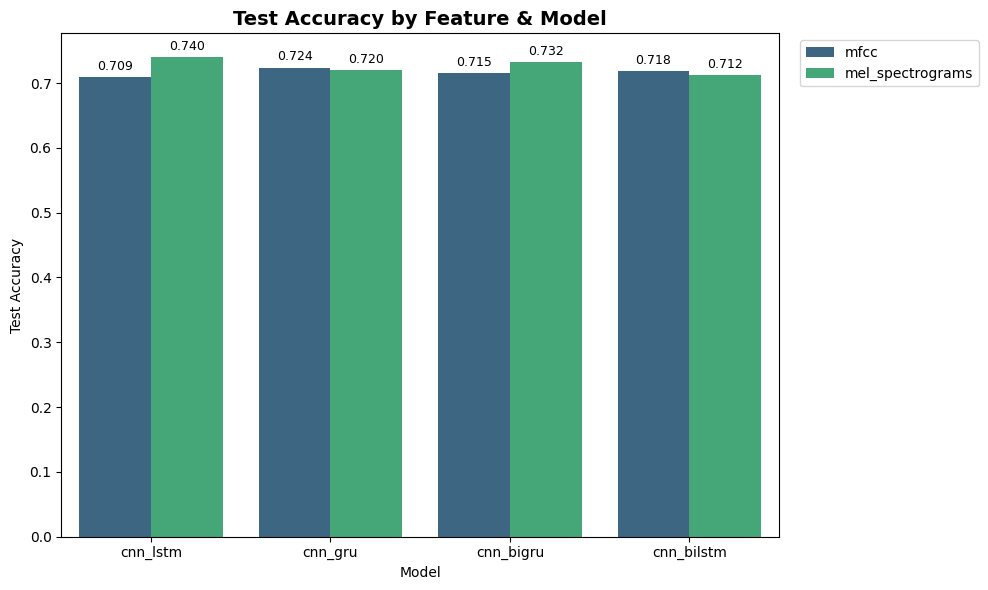

In [42]:
test_acc_df = pd.DataFrame({
    'features': ['mfcc', 'mfcc', 'mfcc', 'mfcc', 'mel_spectrograms', 'mel_spectrograms', 'mel_spectrograms', 'mel_spectrograms'],
    "model": ['cnn_lstm', 'cnn_gru', 'cnn_bigru', 'cnn_bilstm', 'cnn_lstm', 'cnn_gru', 'cnn_bigru', 'cnn_bilstm'],
    'test_acc': [mfcc_cnn_lstm_test_acc, mfcc_cnn_gru_test_acc, mfcc_cnn_bigru_test_acc, mfcc_cnn_bilstm_model_test_acc, mel_cnn_lstm_model_test_acc, mel_cnn_gru_model_test_acc, mel_cnn_bigru_model_test_acc, mel_cnn_bilstm_model_test_acc]
})

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=test_acc_df, x='model', y='test_acc', hue='features', palette='viridis')

ax.set_ylabel('Test Accuracy')
ax.set_xlabel('Model')
ax.set_title('Test Accuracy by Feature & Model', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.bar_label(ax.containers[0], fmt='%.3f', fontsize=9, padding=3)
ax.bar_label(ax.containers[1], fmt='%.3f', fontsize=9, padding=3)
plt.tight_layout()

print("🏆 BEST MODEL:")
print("Features:", test_acc_df.sort_values(by="test_acc", ascending=False)['features'].iloc[0])
print("Model:", test_acc_df.sort_values(by="test_acc", ascending=False)['model'].iloc[0])
print("Test Accuracy:", test_acc_df.sort_values(by="test_acc", ascending=False)['test_acc'].iloc[0])

In [31]:
def evaluate_song_level(model, X_file_test, y_file_test, scaler, feature_type):
    genre_predictions = []
    for i, file_path in enumerate(X_file_test):
        if feature_type == "mel":
            segments = extract_mel_segments(file_path)
        else:
            segments = extract_mfcc_segments(file_path, n_mfcc=20)
        X_test = []
        for segment in segments:
            X_test.append(segment)
        X_test = np.array(X_test)
        X_test_reshaped = X_test.reshape(X_test.shape[0], -1)
        X_test_scaled = scaler.transform(X_test_reshaped)
        X_test = X_test_scaled.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2])
        X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)
        y_prob = model.predict(X_test, verbose=0)
        song_prob = np.mean(y_prob, axis=0)
        predicted_label = np.argmax(song_prob)
        genre_predictions.append(predicted_label)

    accuracy = accuracy_score(y_file_test, genre_predictions)
    return accuracy

In [ ]:
# Load all models
mel_cnn_lstm_model = load_model("/kaggle/input/music-genre-classification-v2-noleakage/model/mel_cnn_lstm_model.h5")
mel_cnn_gru_model = load_model("/kaggle/input/music-genre-classification-v2-noleakage/model/mel_cnn_gru_model.h5")
mel_cnn_bigru_model = load_model("/kaggle/input/music-genre-classification-v2-noleakage/model/mel_cnn_bigru_model.h5")
mel_cnn_bilstm_model = load_model("/kaggle/input/music-genre-classification-v2-noleakage/model/mel_cnn_bilstm_model.h5")

mfcc_cnn_lstm_model = load_model("/kaggle/input/music-genre-classification-v2-noleakage/model/mfcc_cnn_lstm_model.h5")
mfcc_cnn_gru_model = load_model("/kaggle/input/music-genre-classification-v2-noleakage/model/mfcc_cnn_gru_model.h5")
mfcc_cnn_bigru_model = load_model("/kaggle/input/music-genre-classification-v2-noleakage/model/mfcc_cnn_bigru_model.h5")
mfcc_cnn_bilstm_model = load_model("/kaggle/input/music-genre-classification-v2-noleakage/model/mfcc_cnn_bilstm_model.h5")

In [32]:
# Evaluate on song level

mel_cnn_lstm_model_test_acc_song = evaluate_song_level(mel_cnn_lstm_model, X_file_test, y_file_test, scaler_aug_mel, feature_type="mel")
mel_cnn_gru_model_test_acc_song = evaluate_song_level(mel_cnn_gru_model, X_file_test, y_file_test, scaler_aug_mel, feature_type="mel")
mel_cnn_bigru_model_test_acc_song = evaluate_song_level(mel_cnn_bigru_model, X_file_test, y_file_test, scaler_aug_mel, feature_type="mel")
mel_cnn_bilstm_model_test_acc_song =  evaluate_song_level(mel_cnn_bilstm_model, X_file_test, y_file_test, scaler_aug_mel, feature_type="mel")

mfcc_cnn_lstm_model_test_acc_song = evaluate_song_level(mfcc_cnn_lstm_model, X_file_test, y_file_test, scaler_aug_mfcc, feature_type="mfcc")
mfcc_cnn_gru_model_test_acc_song = evaluate_song_level(mfcc_cnn_gru_model, X_file_test, y_file_test, scaler_aug_mfcc, feature_type="mfcc")
mfcc_cnn_bigru_model_test_acc_song = evaluate_song_level(mfcc_cnn_bigru_model, X_file_test, y_file_test, scaler_aug_mfcc, feature_type="mfcc")
mfcc_cnn_bilstm_model_test_acc_song =  evaluate_song_level(mfcc_cnn_bilstm_model, X_file_test, y_file_test, scaler_aug_mfcc, feature_type="mfcc")

In [33]:
print("PERFORMANCE ON SONG-LEVEL EVALUATION")
print("="*60)
print("MFCC CNN+LSTM:", mfcc_cnn_lstm_model_test_acc_song)
print("MFCC CNN+GRU:",  mfcc_cnn_gru_model_test_acc_song)
print("MFCC CNN+Bi-LSTM:", mfcc_cnn_bilstm_model_test_acc_song)
print("MFCC CNN+Bi-GRU:", mfcc_cnn_bigru_model_test_acc_song)
print("Mel CNN+LSTM:", mel_cnn_lstm_model_test_acc_song)
print("Mel CNN+GRU:", mel_cnn_gru_model_test_acc_song)
print("Mel CNN+Bi-LSTM:", mel_cnn_bilstm_model_test_acc_song)
print("Mel CNN+Bi-GRU:", mel_cnn_bigru_model_test_acc_song)

PERFORMANCE ON SONG-LEVEL EVALUATION
MFCC CNN+LSTM: 0.79
MFCC CNN+GRU: 0.83
MFCC CNN+Bi-LSTM: 0.79
MFCC CNN+Bi-GRU: 0.78
Mel CNN+LSTM: 0.85
Mel CNN+GRU: 0.84
Mel CNN+Bi-LSTM: 0.83
Mel CNN+Bi-GRU: 0.85


🏆 BEST MODEL:
Features: mel_spectrograms
Model: cnn_lstm
Test Accuracy (Song): 0.85


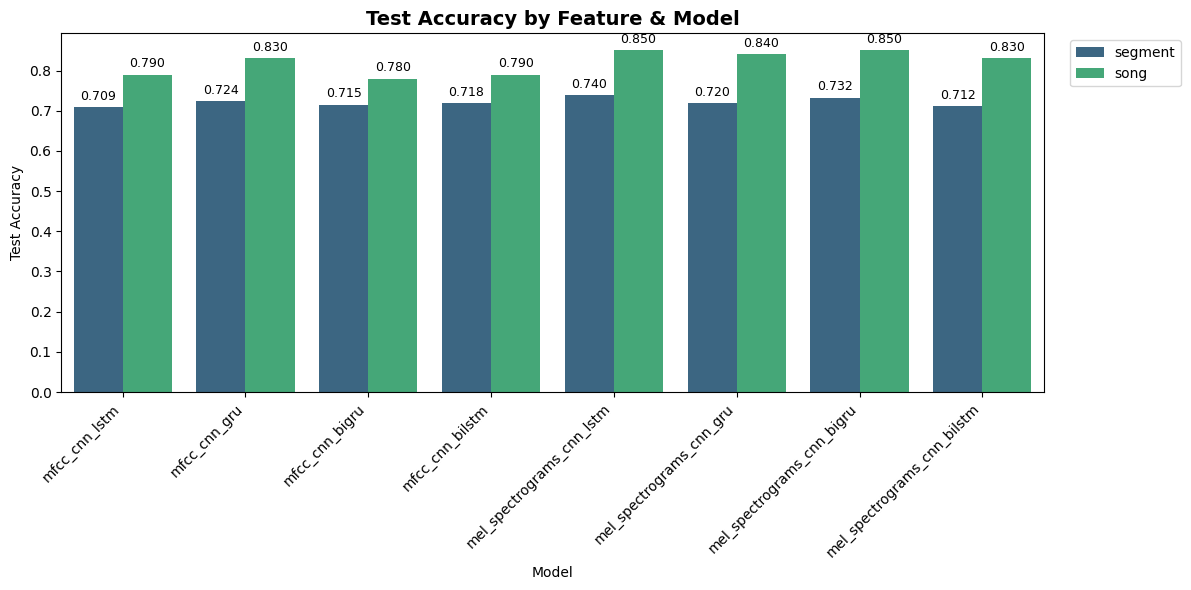

In [35]:
test_acc_df = pd.DataFrame({
    'features': ['mfcc', 'mfcc', 'mfcc', 'mfcc', 'mel_spectrograms', 'mel_spectrograms', 'mel_spectrograms', 'mel_spectrograms', 'mfcc', 'mfcc', 'mfcc', 'mfcc', 'mel_spectrograms', 'mel_spectrograms', 'mel_spectrograms', 'mel_spectrograms'],
    "model": ['cnn_lstm', 'cnn_gru', 'cnn_bigru', 'cnn_bilstm', 'cnn_lstm', 'cnn_gru', 'cnn_bigru', 'cnn_bilstm', 'cnn_lstm', 'cnn_gru', 'cnn_bigru', 'cnn_bilstm', 'cnn_lstm', 'cnn_gru', 'cnn_bigru', 'cnn_bilstm'],
    'evaluation_level': ['segment', 'segment', 'segment', 'segment', 'segment', 'segment', 'segment', 'segment', 'song', 'song', 'song', 'song', 'song', 'song', 'song', 'song'],
    'test_acc': [mfcc_cnn_lstm_test_acc, mfcc_cnn_gru_test_acc, mfcc_cnn_bigru_test_acc, mfcc_cnn_bilstm_model_test_acc, mel_cnn_lstm_model_test_acc, mel_cnn_gru_model_test_acc, mel_cnn_bigru_model_test_acc, mel_cnn_bilstm_model_test_acc,
                mfcc_cnn_lstm_model_test_acc_song, mfcc_cnn_gru_model_test_acc_song, mfcc_cnn_bigru_model_test_acc_song, mfcc_cnn_bilstm_model_test_acc_song, mel_cnn_lstm_model_test_acc_song, mel_cnn_gru_model_test_acc_song, mel_cnn_bigru_model_test_acc_song, mel_cnn_bilstm_model_test_acc_song]
})

test_acc_df['features_model'] = test_acc_df['features'] + "_" + test_acc_df['model']

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=test_acc_df, x='features_model', y='test_acc', hue='evaluation_level', palette='viridis')

ax.set_ylabel('Test Accuracy')
ax.set_xlabel('Model')
ax.set_title('Test Accuracy by Feature & Model', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.bar_label(ax.containers[0], fmt='%.3f', fontsize=9, padding=3)
ax.bar_label(ax.containers[1], fmt='%.3f', fontsize=9, padding=3)
plt.tight_layout()

print("🏆 BEST MODEL:")
print("Features:", test_acc_df.sort_values(by="test_acc", ascending=False)['features'].iloc[0])
print("Model:", test_acc_df.sort_values(by="test_acc", ascending=False)['model'].iloc[0])
print("Test Accuracy (Song):", test_acc_df.sort_values(by="test_acc", ascending=False)['test_acc'].iloc[0])